# `ggrepel_py` examples

Python port of the scenarios in `pkgdown/articles/examples_v2.Rmd`. Covers
hiding labels, always showing overlapping labels, disabling point repulsion,
disabling panel-edge repulsion, nudging, segment styling, curves, and
arrows.

In [1]:
import numpy as np
import pandas as pd
import grid_py as grid
from grid_py import Unit, arrow
from ggplot2_py import (
    ggplot, aes, geom_point, geom_segment, labs, theme_classic,
    scale_x_continuous, expansion,
)
from ggrepel_py import geom_text_repel, geom_label_repel
from ggrepel_py.data import load_mtcars

mtcars = load_mtcars()

## Hide some of the labels

Set a label to the empty string to hide it. All data points still repel the
non-empty labels.

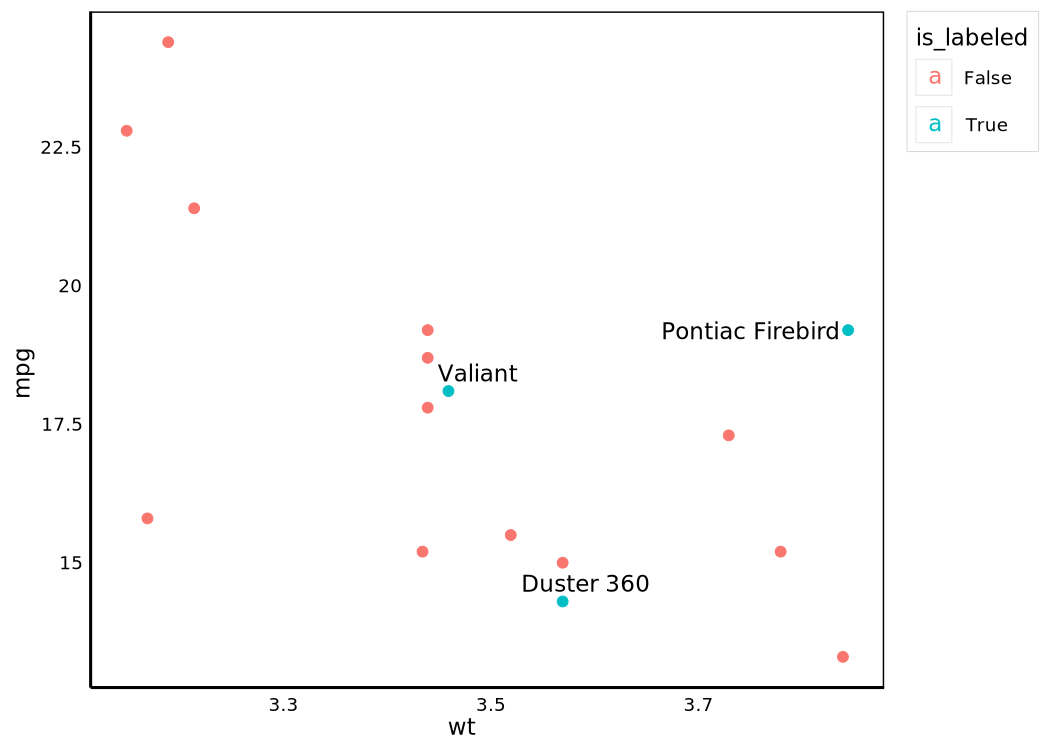

In [2]:
dat2 = mtcars[(mtcars['wt'] > 3) & (mtcars['wt'] < 4)].copy().reset_index(drop=True)
# Only keep a few labels.
keep = [2, 3, 13]
dat2['label'] = ''
dat2.loc[keep, 'label'] = dat2.loc[keep, 'car']
dat2['is_labeled'] = dat2['label'] != ''

(ggplot(dat2, aes(x='wt', y='mpg', label='label'))
 + geom_text_repel(seed=42)
 + geom_point(aes(color='is_labeled'))
 + theme_classic())

## Always show all labels, even with many overlaps

Labels are discarded if they overlap more than `max_overlaps` other things
(default 10). Raise the cap with `max_overlaps=float('inf')` to force every
label to be drawn.

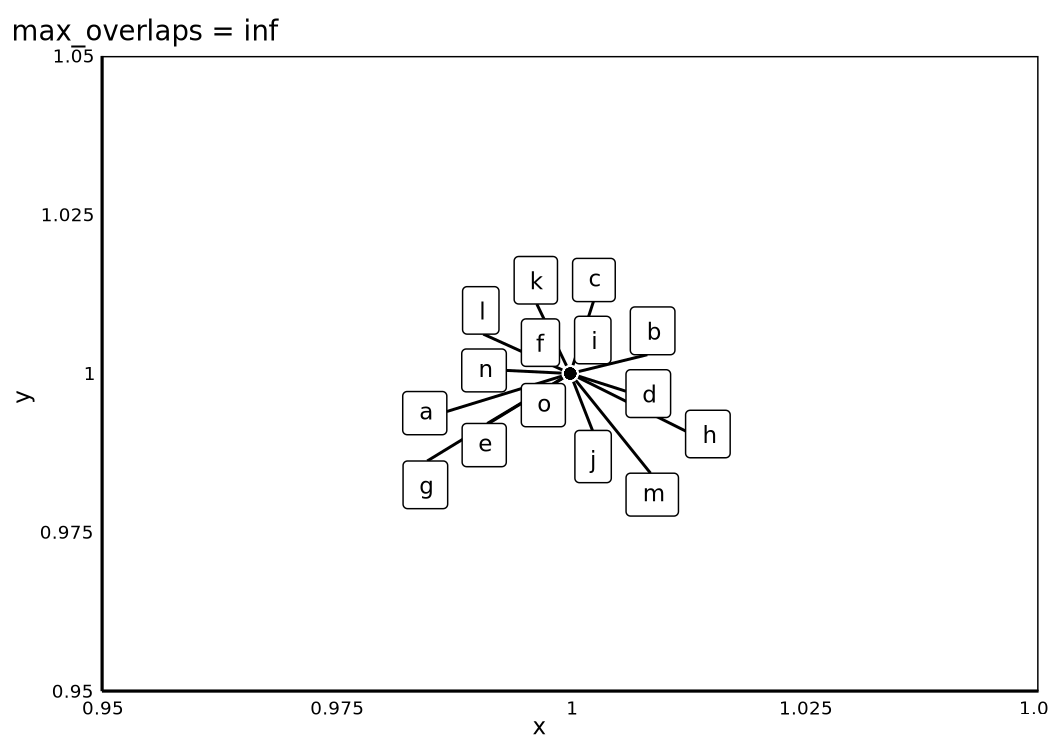

In [3]:
n = 15
dat4 = pd.DataFrame({
    'x': np.ones(n), 'y': np.ones(n),
    'label': [chr(ord('a') + i) for i in range(n)],
})

(ggplot(dat4, aes(x='x', y='y', label='label'))
 + geom_point()
 + geom_label_repel(seed=42, box_padding=0.5, max_overlaps=float('inf'))
 + theme_classic()
 + labs(title='max_overlaps = inf'))

## Do not repel labels from data points

Set `point_size=None` (the Python equivalent of R's `point.size = NA`) to
prevent labels from repelling away from data points. Labels still repel each
other and the panel edges.

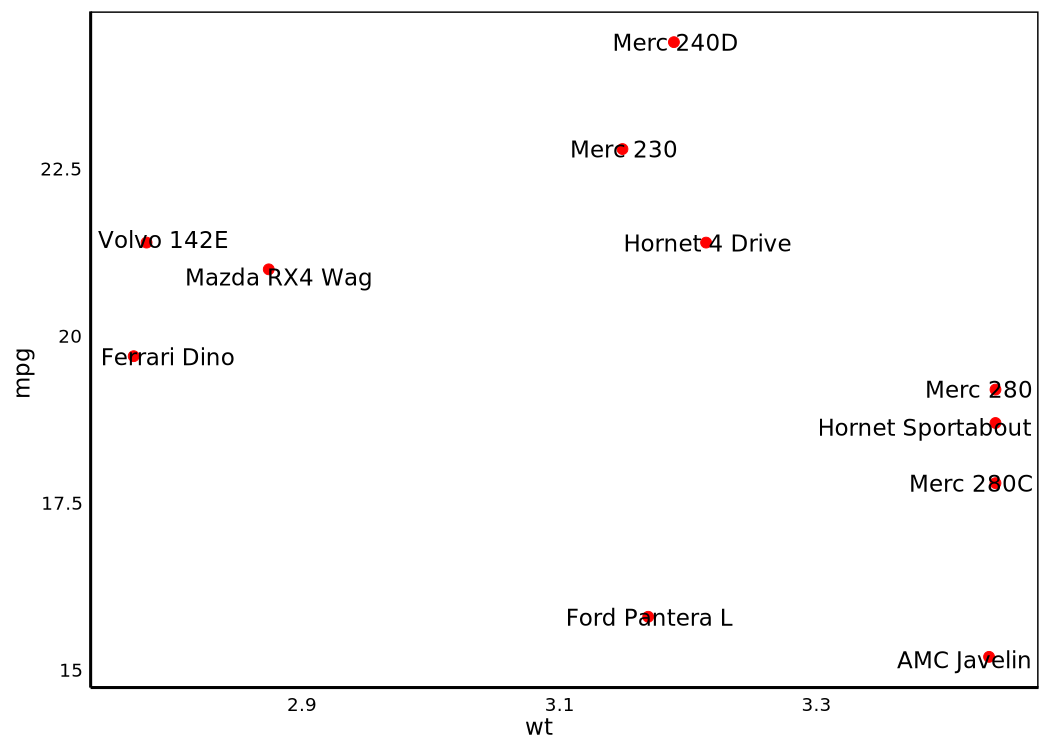

In [4]:
dat = mtcars[(mtcars['wt'] > 2.75) & (mtcars['wt'] < 3.45)].copy()
(ggplot(dat, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_text_repel(seed=42, point_size=None)
 + theme_classic())

## Do not repel labels from plot edges

`xlim`/`ylim` accept `(None, None)` (edge repulsion on both sides, default),
`(None, float('inf'))` to disable one side, or `(-float('inf'), float('inf'))`
to disable edge repulsion entirely. `None` means "use the scale's panel edge".

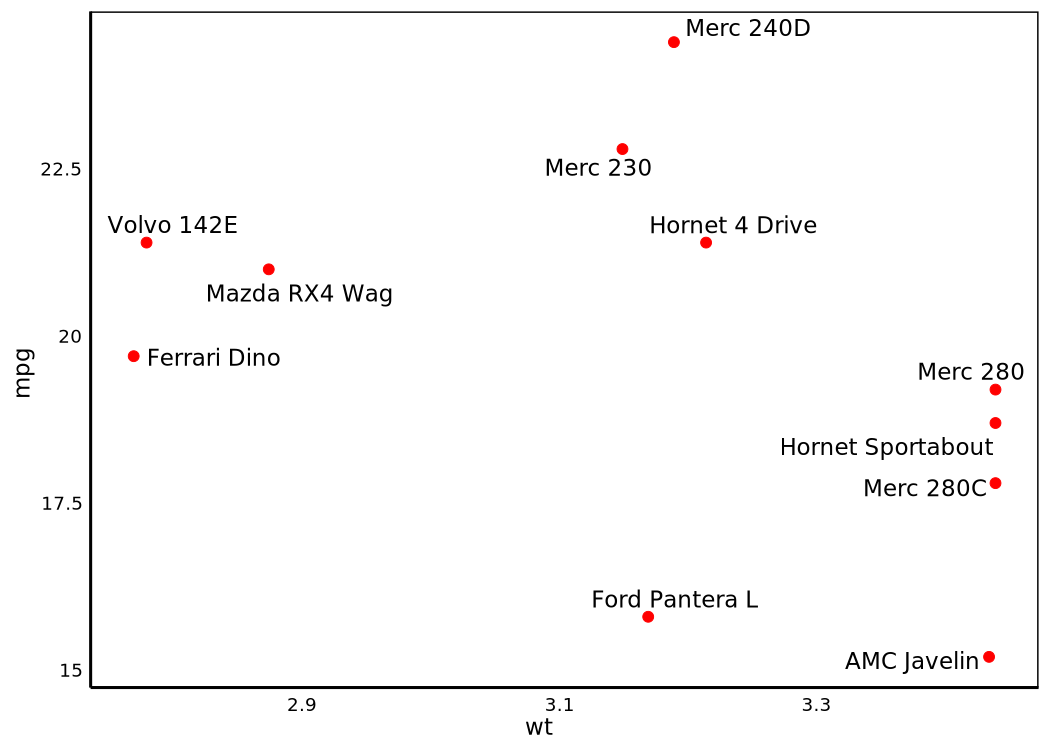

In [5]:
(ggplot(dat, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_text_repel(
     seed=42,
     xlim=(None, float('inf')),           # repel away from left only
     ylim=(-float('inf'), float('inf'))   # don't repel from top/bottom
   )
 + theme_classic())

## Nudging & directional repulsion

Use `nudge_x` / `nudge_y` to set the initial label offset, and
`direction="x"` or `direction="y"` to restrict movement to one axis. Useful
for producing columns of labels either side of a scatterplot.

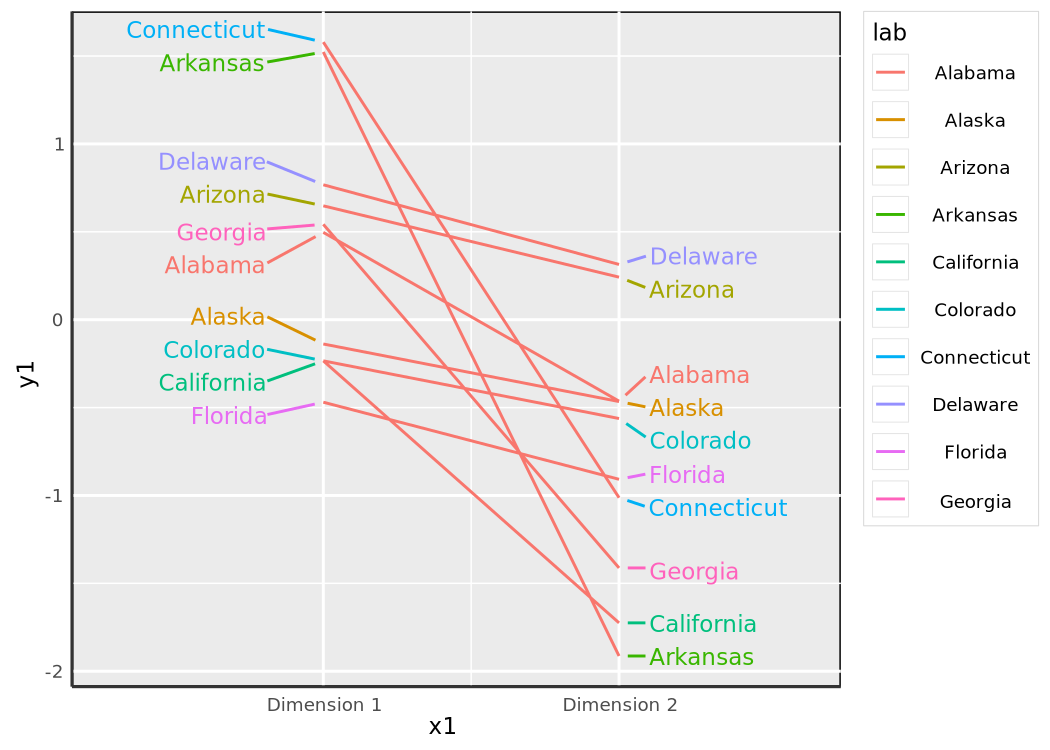

In [6]:
np.random.seed(42)
d = pd.DataFrame({
    'x1': 1.0,
    'y1': np.random.normal(size=10),
    'x2': 2.0,
    'y2': np.random.normal(size=10),
    'lab': ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
             'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia'],
})

p = (ggplot(d, aes(x='x1', y='y1', xend='x2', yend='y2', label='lab', color='lab'))
     + geom_segment(size=1)
     + geom_text_repel(nudge_x=-0.2, direction='y', hjust='right', seed=42)
     + geom_text_repel(aes(x='x2', y='y2'),
                        nudge_x=0.1, direction='y', hjust='left', seed=42))
p + scale_x_continuous(breaks=[1, 2],
                       labels=['Dimension 1', 'Dimension 2'],
                       expand=expansion(mult=0.5))

## Always (or never) draw line segments

- `min_segment_length=0` — always draw a segment from point to label.
- `min_segment_length=float('inf')` — never draw any segments.

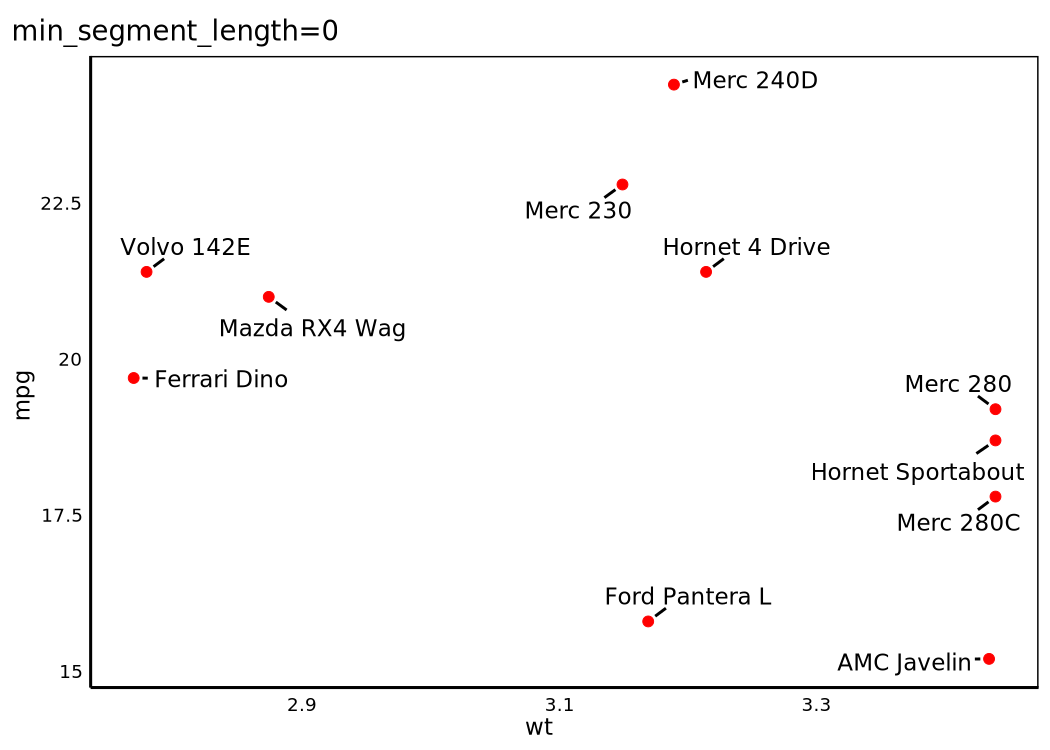

In [7]:
p_all = (ggplot(dat, aes(x='wt', y='mpg', label='car'))
         + geom_point(color='red')
         + geom_text_repel(min_segment_length=0, seed=42, box_padding=0.5)
         + theme_classic()
         + labs(title='min_segment_length=0'))
p_all

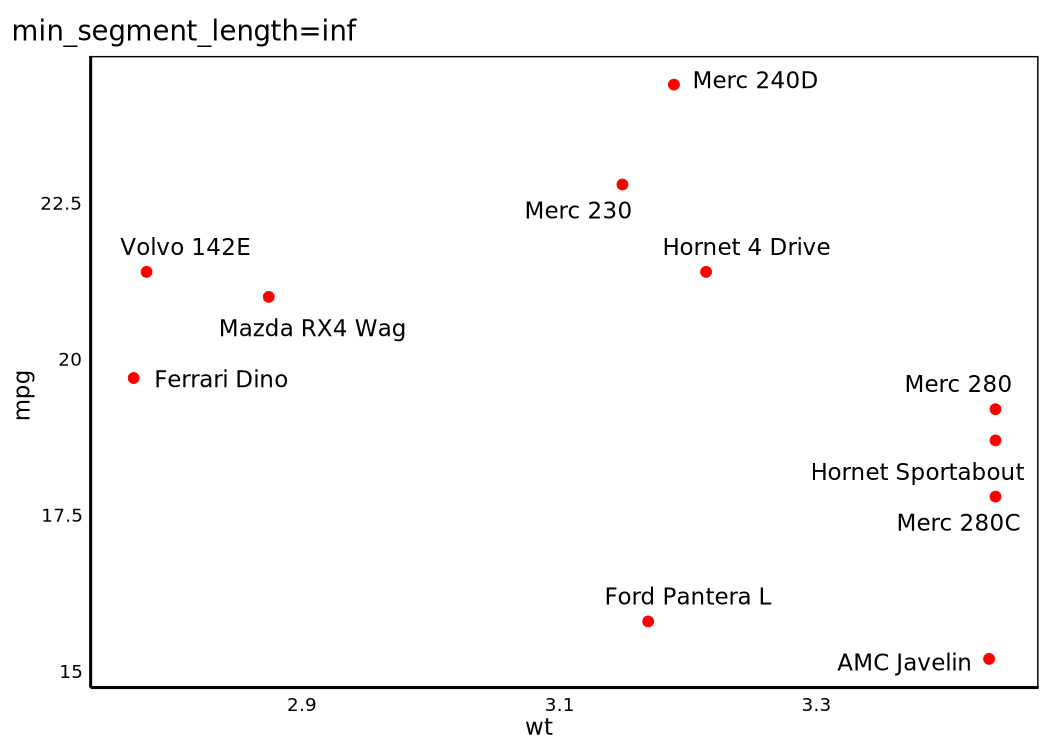

In [8]:
p_none = (ggplot(dat, aes(x='wt', y='mpg', label='car'))
          + geom_point(color='red')
          + geom_text_repel(min_segment_length=float('inf'),
                              seed=42, box_padding=0.5)
          + theme_classic()
          + labs(title="min_segment_length=inf"))
p_none

## Curved segments and arrows

Segment curvature is controlled by `segment_curvature`, `segment_ncp`, and
`segment_angle`. Use `arrow=grid_py.arrow(...)` to add arrow heads.

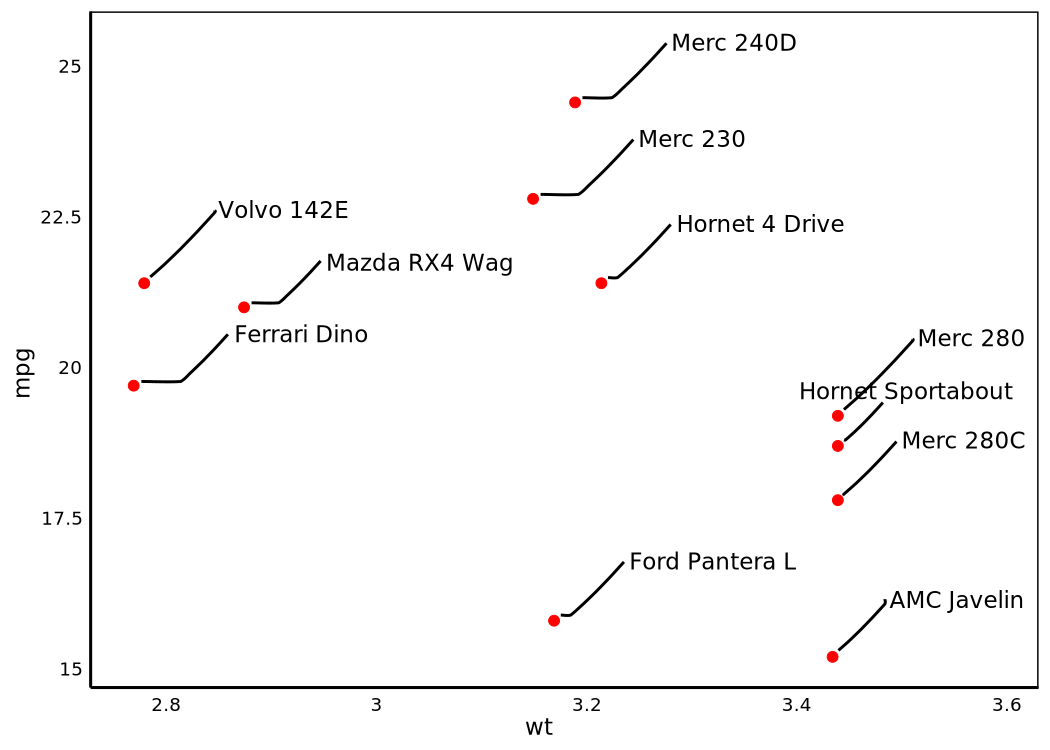

In [9]:
(ggplot(dat, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_text_repel(
     nudge_x=0.15, nudge_y=1,
     box_padding=0.5,
     segment_curvature=-0.1,
     segment_ncp=3,
     segment_angle=20,
     seed=42)
 + theme_classic())

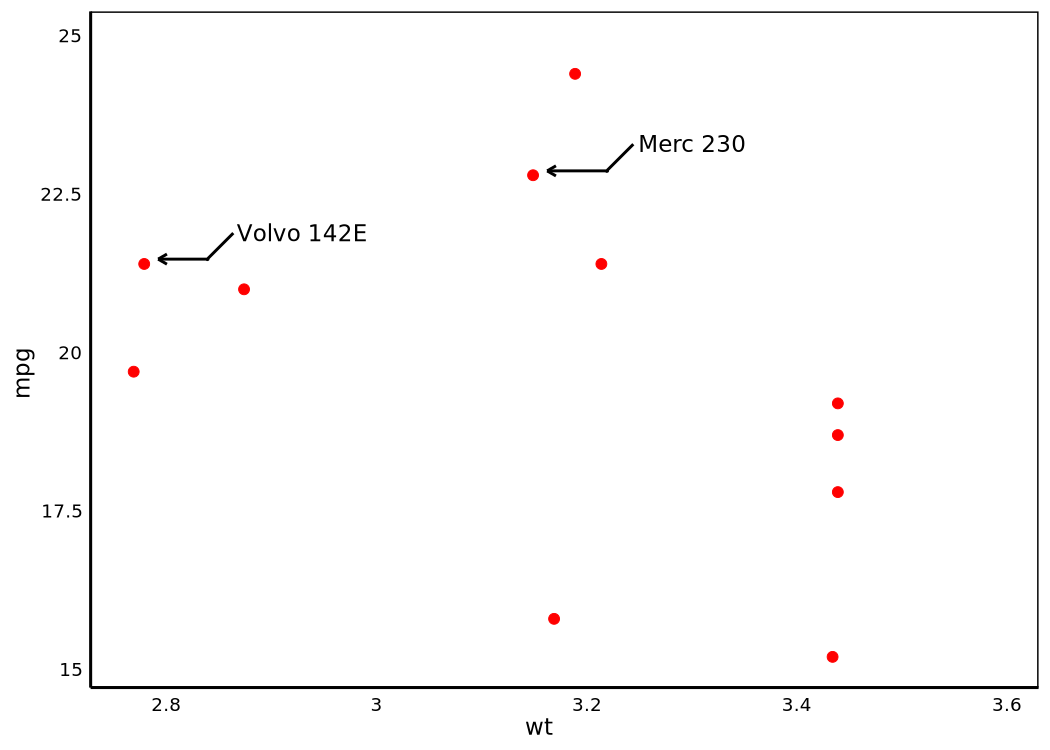

In [10]:
# Near-zero curvature + arrow head.
cars = ['Volvo 142E', 'Merc 230']
dat_annot = dat.copy()
dat_annot['label'] = dat_annot['car'].where(dat_annot['car'].isin(cars), '')

(ggplot(dat_annot, aes(x='wt', y='mpg', label='label'))
 + geom_point(color='red')
 + geom_text_repel(
     point_padding=0.2,
     nudge_x=0.15, nudge_y=0.5,
     segment_curvature=-1e-20,
     arrow=arrow(length=Unit(0.015, 'npc')),
     seed=42)
 + theme_classic())

## Custom line types and segment colors

`segment_linetype` takes the same integer codes as ggplot2 (1 solid, 2 dashed,
3 dotted, 4 dotdash, 5 longdash, 6 twodash). `segment_colour` overrides the
default (`colour`) for the segment only.

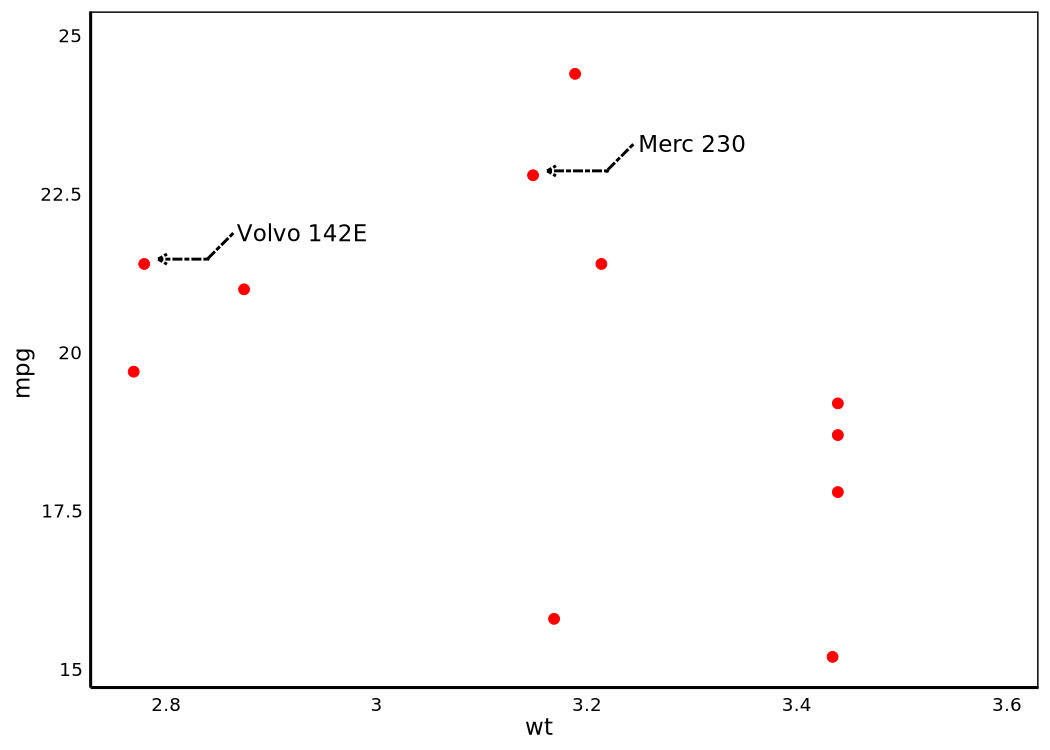

In [11]:
(ggplot(dat_annot, aes(x='wt', y='mpg', label='label'))
 + geom_point(color='red')
 + geom_text_repel(
     point_padding=0.2,
     nudge_x=0.15, nudge_y=0.5,
     segment_linetype=6,
     segment_curvature=-1e-20,
     arrow=arrow(length=Unit(0.015, 'npc')),
     seed=42)
 + theme_classic())

## Closed arrows with custom fill color

`arrow_fill` controls the fill color for closed arrow heads independently of
`segment_colour`. Defaults to the segment color.

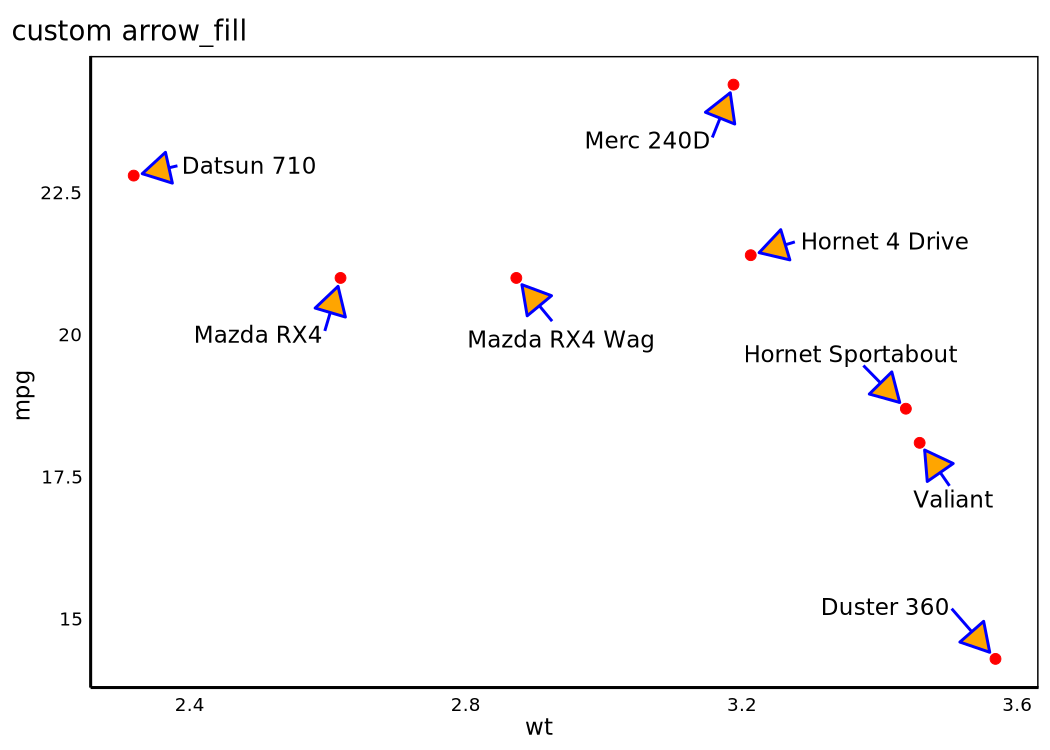

In [12]:
df8 = mtcars.head(8).copy()
(ggplot(df8, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_text_repel(
     min_segment_length=0,
     segment_colour='blue',
     arrow_fill='orange',
     segment_linetype=1,
     arrow=arrow(length=Unit(0.05, 'npc'), type='closed'),
     box_padding=1.5,
     seed=42)
 + theme_classic()
 + labs(title='custom arrow_fill'))

## Deterministic output

Always pass `seed=` when you need reproducible layouts. The same seed produces
byte-identical label coordinates in the same version of `ggrepel_py`.